# Task 2 — Bagging with Undersampling

This notebook completes Task 2 from the homework. The executable implementation is in `task2_bagging.py`, while this notebook adds explanations, formulas, experiment tables, and plots.


## Imports and Shared Code

The bagging logic is implemented in `BaggingImbalanced`. The class supports two base learners:

- `base_learner="hddt"`: the Hellinger Distance Decision Tree from Task 1.
- `base_learner="dt"`: sklearn's `DecisionTreeClassifier`, allowed here because the homework explicitly asks for this comparison.

Preprocessing is reused from Task 1 and is fit only on each training split.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / "code"))

from task2_bagging import (
    T_VALUES,
    BaggingImbalanced,
    format_mean_std_table,
    plot_t_experiment,
    run_bagging_experiments,
    run_base_learner_comparison,
    run_ensemble_size_experiment,
)
from task1_hddt import (
    SEEDS,
    compute_metrics,
    preprocess_train_test,
    resolve_dataset_path,
)


## Load the Dataset

The target label is `+1` for severe COVID cases and `-1` for non-severe cases. The dataset is highly imbalanced, so a regular bootstrap sample would mostly contain majority-class examples. Task 2 fixes this by training each base learner on a balanced subset.


In [2]:
data_path = resolve_dataset_path("../Covid.csv")
df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {df.shape}")
print("Class distribution:")
print(df["Label"].value_counts().sort_index())


Dataset path: ../Covid.csv
Dataset shape: (1585, 41)
Class distribution:
Label
-1    1485
 1     100
Name: count, dtype: int64


## Preprocessing Used Inside Each Experiment

For every random seed, the code performs the required preprocessing independently:

1. Stratified 70/30 train/test split.
2. Train-fitted imputation.
3. Kendall feature selection on the training data only.
4. Standard scaling only if a retained continuous feature exists.

This avoids leakage from the test set into imputation, feature selection, or scaling.


In [3]:
X_train, X_test, y_train, y_test, preprocessing_info = preprocess_train_test(df, seed=42)

print(f"Train shape after preprocessing: {X_train.shape}")
print(f"Test shape after preprocessing: {X_test.shape}")
print(f"Selected features: {len(preprocessing_info['selected_features'])}")
print(f"Continuous scaled features: {preprocessing_info['continuous_scaled']}")
preprocessing_info["removed_features"]


Train shape after preprocessing: (1109, 39)
Test shape after preprocessing: (476, 39)
Selected features: 39
Continuous scaled features: []


,removed_feature,kept_feature,abs_kendall_between_features,removed_abs_corr_with_label,kept_abs_corr_with_label
0,vomiting,nausea,0.766494,0.075083,0.075083


## Bagging with Undersampling Algorithm

For each ensemble member:

1. Let the minority class be `+1` and its size be `m`.
2. Bootstrap sample `m` minority examples with replacement.
3. Randomly undersample `m` majority examples without replacement.
4. Combine them into a balanced training subset of size `2m`.
5. Train one base classifier.

The final prediction is majority vote across the `T` classifiers. The probability used for AUC-ROC is the average predicted positive-class probability across all classifiers.


In [4]:
demo_model = BaggingImbalanced(
    base_learner="hddt",
    T=11,
    max_depth=3,
    min_samples_split=10,
    random_state=42,
)
demo_model.fit(X_train, y_train)

y_pred = demo_model.predict(X_test)
y_score = demo_model.predict_proba(X_test)

pd.DataFrame([compute_metrics(y_test, y_pred, y_score)]).round(4)


,Accuracy,Precision (+1),Recall (+1),F1-score (+1),AUC-ROC,G-mean
0,0.2101,0.0675,0.9,0.1256,0.6402,0.3838


## Experiment 3.3 — Effect of Ensemble Size `T`

The homework asks us to use HDDT as the base learner with `max_depth=3` and test:

`T in {11, 31, 51, 101}`

Each setting is evaluated over 10 stratified splits with seeds `0` through `9`. The table reports mean ± standard deviation across those 10 runs.


In [5]:
t_results = run_ensemble_size_experiment(df, T_values=T_VALUES, seeds=SEEDS)
t_summary = format_mean_std_table(t_results, "T")
t_summary


,T,Accuracy,Precision (+1),Recall (+1),F1-score (+1),AUC-ROC,G-mean
0,11,0.3250 +/- 0.1538,0.0751 +/- 0.0082,0.8400 +/- 0.1570,0.1371 +/- 0.0122,0.6371 +/- 0.0541,0.4615 +/- 0.0927
1,31,0.2819 +/- 0.1102,0.0735 +/- 0.0058,0.8867 +/- 0.1045,0.1355 +/- 0.0091,0.6454 +/- 0.0455,0.4439 +/- 0.0833
2,51,0.2708 +/- 0.0850,0.0734 +/- 0.0053,0.9033 +/- 0.0711,0.1357 +/- 0.0088,0.6492 +/- 0.0452,0.4426 +/- 0.0770
3,101,0.2555 +/- 0.1071,0.0730 +/- 0.0053,0.9167 +/- 0.1021,0.1350 +/- 0.0086,0.6560 +/- 0.0457,0.4191 +/- 0.0936


## Plot G-mean and F1 vs. `T`

Accuracy alone is misleading for this dataset because the majority class dominates. The plot focuses on F1 for the `+1` class and G-mean:

$$
G\text{-}mean = \sqrt{Sensitivity \times Specificity}
$$

A useful ensemble size is one where increasing `T` no longer improves these minority-aware metrics.


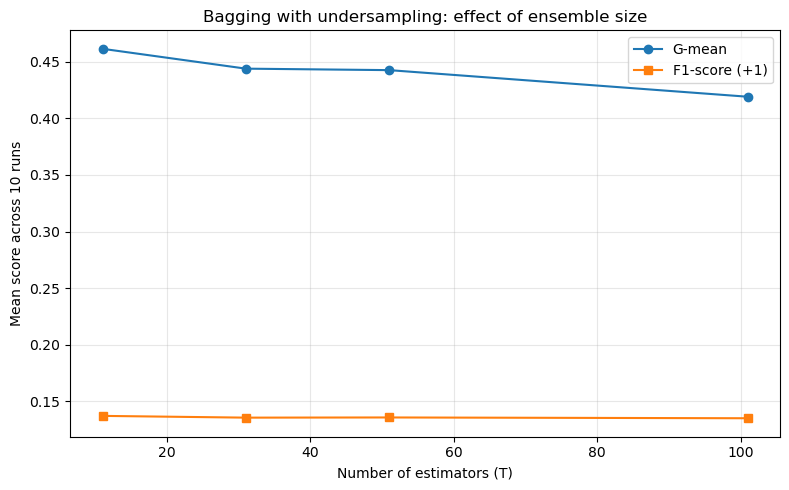

In [6]:
ax = plot_t_experiment(t_results)
plt.show()


## Which `T` Helps Most?

This table sorts the tested ensemble sizes by mean G-mean and then mean F1. It helps answer where increasing `T` stops helping.


In [7]:
t_ranking = (
    t_results
    .groupby("T")[["G-mean", "F1-score (+1)", "Recall (+1)", "Precision (+1)", "Accuracy", "AUC-ROC"]]
    .mean()
    .sort_values(["G-mean", "F1-score (+1)"], ascending=False)
)

t_ranking.round(4)


,G-mean,F1-score (+1),Recall (+1),Precision (+1),Accuracy,AUC-ROC
T,,,,,,
11,0.4615,0.1371,0.8400,0.0751,0.3250,0.6371
31,0.4439,0.1355,0.8867,0.0735,0.2819,0.6454
51,0.4426,0.1357,0.9033,0.0734,0.2708,0.6492
101,0.4191,0.1350,0.9167,0.0730,0.2555,0.6560


## Experiment 3.4 — HDDT vs. Standard Decision Tree Base Learner

The homework asks for `T=51` and `max_depth=3`, comparing:

- Bagging with our HDDT base learner.
- Bagging with sklearn's standard `DecisionTreeClassifier` base learner.

Both methods use exactly the same preprocessing and undersampling ensemble procedure.


In [8]:
comparison_results = run_base_learner_comparison(df, T=51, max_depth=3, seeds=SEEDS)
comparison_table = format_mean_std_table(comparison_results, "base_learner")
comparison_table["base_learner"] = comparison_table["base_learner"].map({
    "hddt": "HDDT (yours)",
    "dt": "Standard DT (sklearn)",
})
comparison_table


,base_learner,Accuracy,Precision (+1),Recall (+1),F1-score (+1),AUC-ROC,G-mean
0,Standard DT (sklearn),0.5345 +/- 0.1529,0.0845 +/- 0.0158,0.6233 +/- 0.1611,0.1474 +/- 0.0245,0.6398 +/- 0.0418,0.5501 +/- 0.0759
1,HDDT (yours),0.2708 +/- 0.0850,0.0734 +/- 0.0053,0.9033 +/- 0.0711,0.1357 +/- 0.0088,0.6492 +/- 0.0452,0.4426 +/- 0.0770


## Base Learner Ranking

G-mean is often more revealing than accuracy for this imbalanced dataset. A model that predicts almost everything as `-1` can still look accurate, but it will have poor minority recall and poor G-mean.


In [9]:
base_ranking = (
    comparison_results
    .groupby("base_learner")[["G-mean", "F1-score (+1)", "Recall (+1)", "Precision (+1)", "Accuracy", "AUC-ROC"]]
    .mean()
    .sort_values(["G-mean", "F1-score (+1)"], ascending=False)
)
base_ranking = base_ranking.rename(index={"hddt": "HDDT (yours)", "dt": "Standard DT (sklearn)"})
base_ranking.round(4)


,G-mean,F1-score (+1),Recall (+1),Precision (+1),Accuracy,AUC-ROC
base_learner,,,,,,
Standard DT (sklearn),0.5501,0.1474,0.6233,0.0845,0.5345,0.6398
HDDT (yours),0.4426,0.1357,0.9033,0.0734,0.2708,0.6492
